<a href="https://colab.research.google.com/github/beecall17/AI-ML-Learning/blob/main/Data-Wrangling/data_wrangling_bikal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load datasets
demographics = pd.read_csv("/content/drive/MyDrive/Fuse AI Fellowship/wk_1_data/patient_demographics.csv")
clinical = pd.read_csv("/content/drive/MyDrive/Fuse AI Fellowship/wk_1_data/clinical_data.csv")
lifestyle = pd.read_csv("/content/drive/MyDrive/Fuse AI Fellowship/wk_1_data/lifestyle_factors.csv")

# Basic Inspection

## Tasks:
- View first few rows
- Check datatypes
- Look at summary statistics

## Questions:
- Are there obvious data issues?
- Are datatypes appropriate?

## Hint:
- Use `.head()`, `.info()`, `.describe()` for all three dataframes to get a full picture of the data quality.
- Pandas documentation for reference: https://pandas.pydata.org/docs/user_guide/10min.html

In [ ]:
# demographics.head()
#The first 5 rows looks normal
demographics.head(10) # looks normal at first inspection

,Patient ID,Age,Sex,Income,Country,Continent,Hemisphere
0,BMW7812,67,Male,261404,Argentina,South America,Southern Hemisphere
1,CZE1114,21,Male,285768,Canada,North America,Northern Hemisphere
2,BNI9906,21,Female,235282,France,Europe,Northern Hemisphere
3,JLN3497,84,Male,125640,Canada,North America,Northern Hemisphere
4,GFO8847,66,Male,160555,Thailand,Asia,Northern Hemisphere
5,ZOO7941,54,Female,241339,Germany,Europe,Northern Hemisphere
6,WYV0966,90,Male,190450,Canada,North America,Northern Hemisphere
7,XXM0972,84,Male,122093,Japan,Asia,Northern Hemisphere
8,XCQ5937,20,Male,25086,Brazil,South America,Southern Hemisphere
9,FTJ5456,43,Female,209703,Japan,Asia,Northern Hemisphere


In [ ]:
clinical.head(10)
#blood pressure is seperated by / and is probably in object

,Patient ID,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Triglycerides,BMI
0,BMW7812,208,158/88,72,0,0,286,31.251233
1,CZE1114,389,165/93,98,1,1,235,27.194973
2,BNI9906,324,174/99,72,1,0,587,28.176571
3,JLN3497,383,163/100,73,1,1,378,36.464704
4,GFO8847,318,91/88,93,1,1,231,21.809144
5,ZOO7941,297,172/86,48,1,1,795,20.146840
6,WYV0966,358,102/73,84,0,0,284,28.885811
7,XXM0972,220,131/68,107,0,0,370,22.221862
8,XCQ5937,145,144/105,68,1,0,790,35.809901
9,FTJ5456,248,160/70,55,0,1,232,22.558917


In [ ]:
lifestyle.tail(10)
#looking at last 10 rows for this
# all three sheets/csv looks normal at first glance

,Patient ID,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Diet,Stress Level,Heart Attack Risk
8753,NVC8704,1,1,1,8.202449,Unhealthy,7,1
8754,LZM3606,1,0,1,6.082656,Healthy,3,1
8755,KQR8949,1,0,1,3.272202,Average,3,0
8756,BUE0416,1,0,1,3.820772,Healthy,1,1
8757,YDX2478,1,1,0,1.857908,Healthy,4,0
8758,MSV9918,1,0,1,7.917342,Healthy,8,0
8759,QSV6764,0,1,0,16.558426,Healthy,8,0
8760,XKA5925,1,1,1,3.148438,Average,5,1
8761,EPE6801,1,0,0,3.789950,Unhealthy,5,0
8762,ZWN9666,0,0,1,18.081748,Healthy,8,1


In [ ]:
demographics.info()
# this looks normal datatypes and no missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Patient ID  8763 non-null   object
 1   Age         8763 non-null   int64 
 2   Sex         8763 non-null   object
 3   Income      8763 non-null   int64 
 4   Country     8763 non-null   object
 5   Continent   8763 non-null   object
 6   Hemisphere  8763 non-null   object
dtypes: int64(2), object(5)
memory usage: 479.4+ KB


In [ ]:
clinical.info()
#as suspected bp in object

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Patient ID      8763 non-null   object 
 1   Cholesterol     8763 non-null   int64  
 2   Blood Pressure  8763 non-null   object 
 3   Heart Rate      8763 non-null   int64  
 4   Diabetes        8763 non-null   int64  
 5   Family History  8763 non-null   int64  
 6   Triglycerides   8763 non-null   int64  
 7   BMI             8763 non-null   float64
dtypes: float64(1), int64(5), object(2)
memory usage: 547.8+ KB


In [ ]:
lifestyle.info()
#looks no null values here as well we will confirm with .isna.sum also.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Patient ID               8763 non-null   object 
 1   Smoking                  8763 non-null   int64  
 2   Obesity                  8763 non-null   int64  
 3   Alcohol Consumption      8763 non-null   int64  
 4   Exercise Hours Per Week  8763 non-null   float64
 5   Diet                     8763 non-null   object 
 6   Stress Level             8763 non-null   int64  
 7   Heart Attack Risk        8763 non-null   int64  
dtypes: float64(1), int64(5), object(2)
memory usage: 547.8+ KB


In [ ]:
demographics.describe()

,Age,Income
count,8763.000000,8763.000000
mean,53.707977,158263.181901
std,21.249509,80575.190806
min,18.000000,20062.000000
25%,35.000000,88310.000000
50%,54.000000,157866.000000
75%,72.000000,227749.000000
max,90.000000,299954.000000


In [ ]:
clinical.describe()
#looking at the min, max and quartile ranges the data looks symmetrical at first glance.

,Cholesterol,Heart Rate,Diabetes,Family History,Triglycerides,BMI
count,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000
mean,259.877211,75.021682,0.652288,0.492982,417.677051,28.891446
std,80.863276,20.550948,0.476271,0.499979,223.748137,6.319181
min,120.000000,40.000000,0.000000,0.000000,30.000000,18.002337
25%,192.000000,57.000000,0.000000,0.000000,225.500000,23.422985
50%,259.000000,75.000000,1.000000,0.000000,417.000000,28.768999
75%,330.000000,93.000000,1.000000,1.000000,612.000000,34.324594
max,400.000000,110.000000,1.000000,1.000000,800.000000,39.997211


Addressing the incorrect datatype Object on clinical BP

In [ ]:
clinical['Blood Pressure'].head()

,Blood Pressure
0,158/88
1,165/93
2,174/99
3,163/100
4,91/88


In [ ]:
# clinical['Blood Pressure'].mean()
#Results into error for mean on str / object

In [ ]:
clinical[['Systolic', 'Diastolic']] = clinical['Blood Pressure'].str.split('/', expand=True).astype(int)
clinical
#created two new columns Systolic and Diastolic while preserving the original BP column (if we dont need it later we can drop)

,Patient ID,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Triglycerides,BMI,Systolic,Diastolic
0,BMW7812,208,158/88,72,0,0,286,31.251233,158,88
1,CZE1114,389,165/93,98,1,1,235,27.194973,165,93
2,BNI9906,324,174/99,72,1,0,587,28.176571,174,99
3,JLN3497,383,163/100,73,1,1,378,36.464704,163,100
4,GFO8847,318,91/88,93,1,1,231,21.809144,91,88
...,...,...,...,...,...,...,...,...,...,...
8758,MSV9918,121,94/76,61,1,1,67,19.655895,94,76
8759,QSV6764,120,157/102,73,1,0,617,23.993866,157,102
8760,XKA5925,250,161/75,105,0,1,527,35.406146,161,75
8761,EPE6801,178,119/67,60,1,0,114,27.294020,119,67


## 2. Missing Values
Checking null-values on all three datasets

In [ ]:
clinical.isna().sum()
#here there are no null values,
#if this dataset had missing values which would be critical missing values for us. As, the missing value probably werent random missing (MNAR).
#The imputation here needs to be vary careful or dropping would be better to make model free from bias.

,0
Patient ID,0
Cholesterol,0
Blood Pressure,0
Heart Rate,0
Diabetes,0
Family History,0
Triglycerides,0
BMI,0


In [ ]:
lifestyle.isna().sum()
#Here the heart attack risk, stress level, obesity, smoking, alcohol consumption columns needs to be filled with caution or drop if the null values is relatively small.
#excerse hours per week and diet could be assume average (mean)

,0
Patient ID,0
Smoking,0
Obesity,0
Alcohol Consumption,0
Exercise Hours Per Week,0
Diet,0
Stress Level,0
Heart Attack Risk,0


In [ ]:
demographics.isna().sum()
#here is sex, country, continent and hemisphere were null then we could fill it with "Unknown" or similar
# for income could assume mean or meadian value
#where as for age, if the predictions depends heavily on age group and the age null values is less we could drop that value

,0
Patient ID,0
Age,0
Sex,0
Income,0
Country,0
Continent,0
Hemisphere,0


# Exploratory Data Analysis (EDA)


### Distribution of Key Numerical Variables

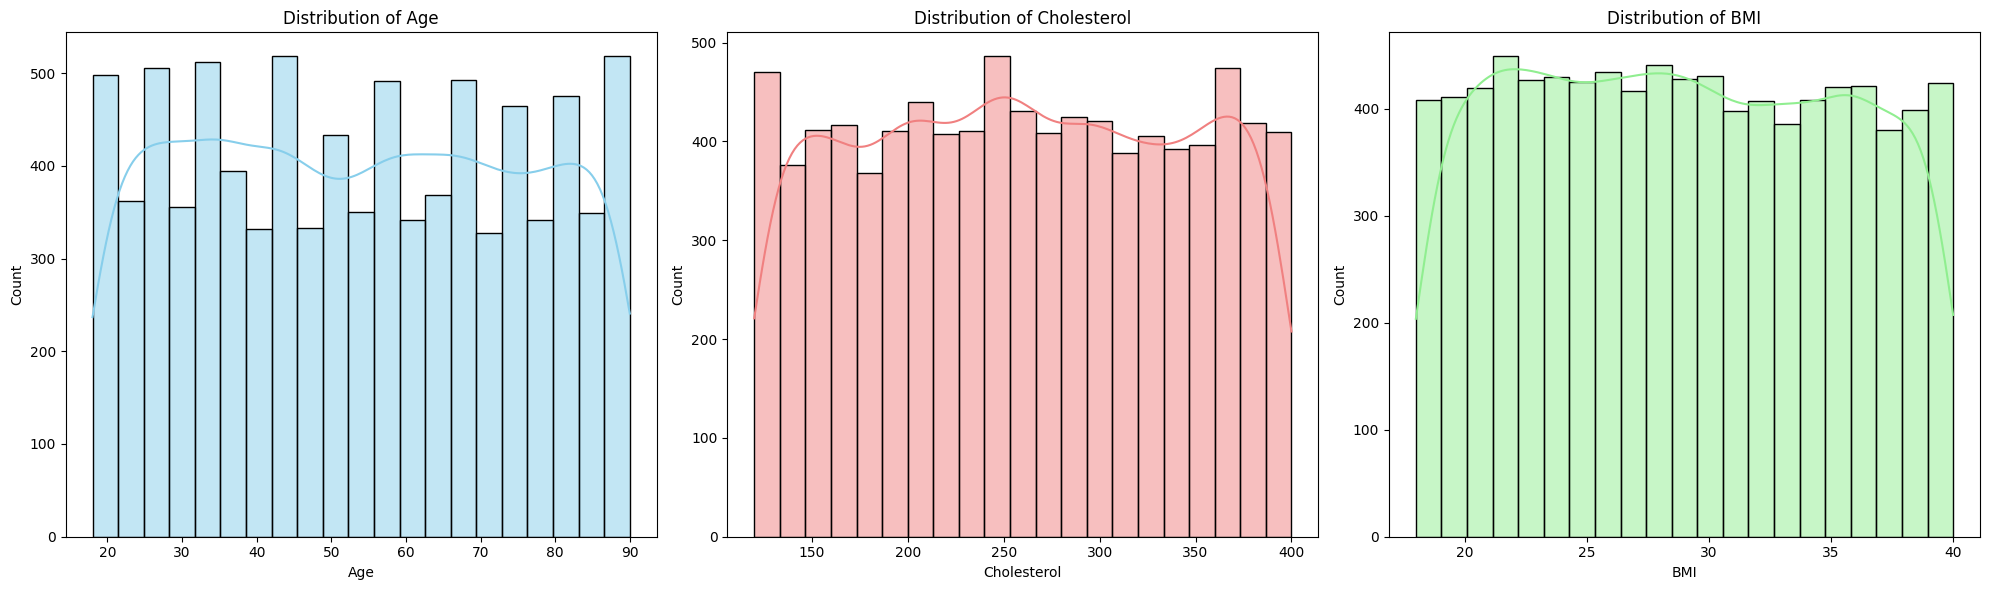

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
sns.histplot(demographics['Age'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Age')

sns.histplot(clinical['Cholesterol'], kde=True, ax=axes[1], color='lightcoral')
axes[1].set_title('Distribution of Cholesterol')

sns.histplot(clinical['BMI'], kde=True, ax=axes[2], color='lightgreen')
axes[2].set_title('Distribution of BMI')

plt.tight_layout()
plt.show()

Plots analysis:
1. All the three plots looks Uniformly distributed
(as no left or right skewness are visible), might be deu to synthetic data.
2. All the plots, dont show any specific outliers present.


Age Distribution:
1. all the data points roughly falls between 300 to 500 counts.
2. the data points fall in between 18-90 age group.

Cholestrol:
1. The KDE line is slightly wave
2. the 140, 250 and 380 data are high then the rest of data

BMI:
1. Among others, this plot shows stable uniform distribution.
2. All the data points ranging from 18 to 40 falls closly on 400 (between 350 to 450 ) counts
3. There doenst seems to be a Mode (highest value on any range).




## 2. Categorical Variables : Bar Charts

### Task:
Plot bar charts showing the frequency distribution of: Smoking Status, Diet Quality, and Top 10 Countries

### Questions:
- What proportion of patients smoke?
- Which diet category is most common?
- Which countries are most represented?

### Why This Matters:
Imbalanced categories (e.g., 90% male patients) can introduce bias into analyses. Knowing category proportions helps interpret group-level results accurately.

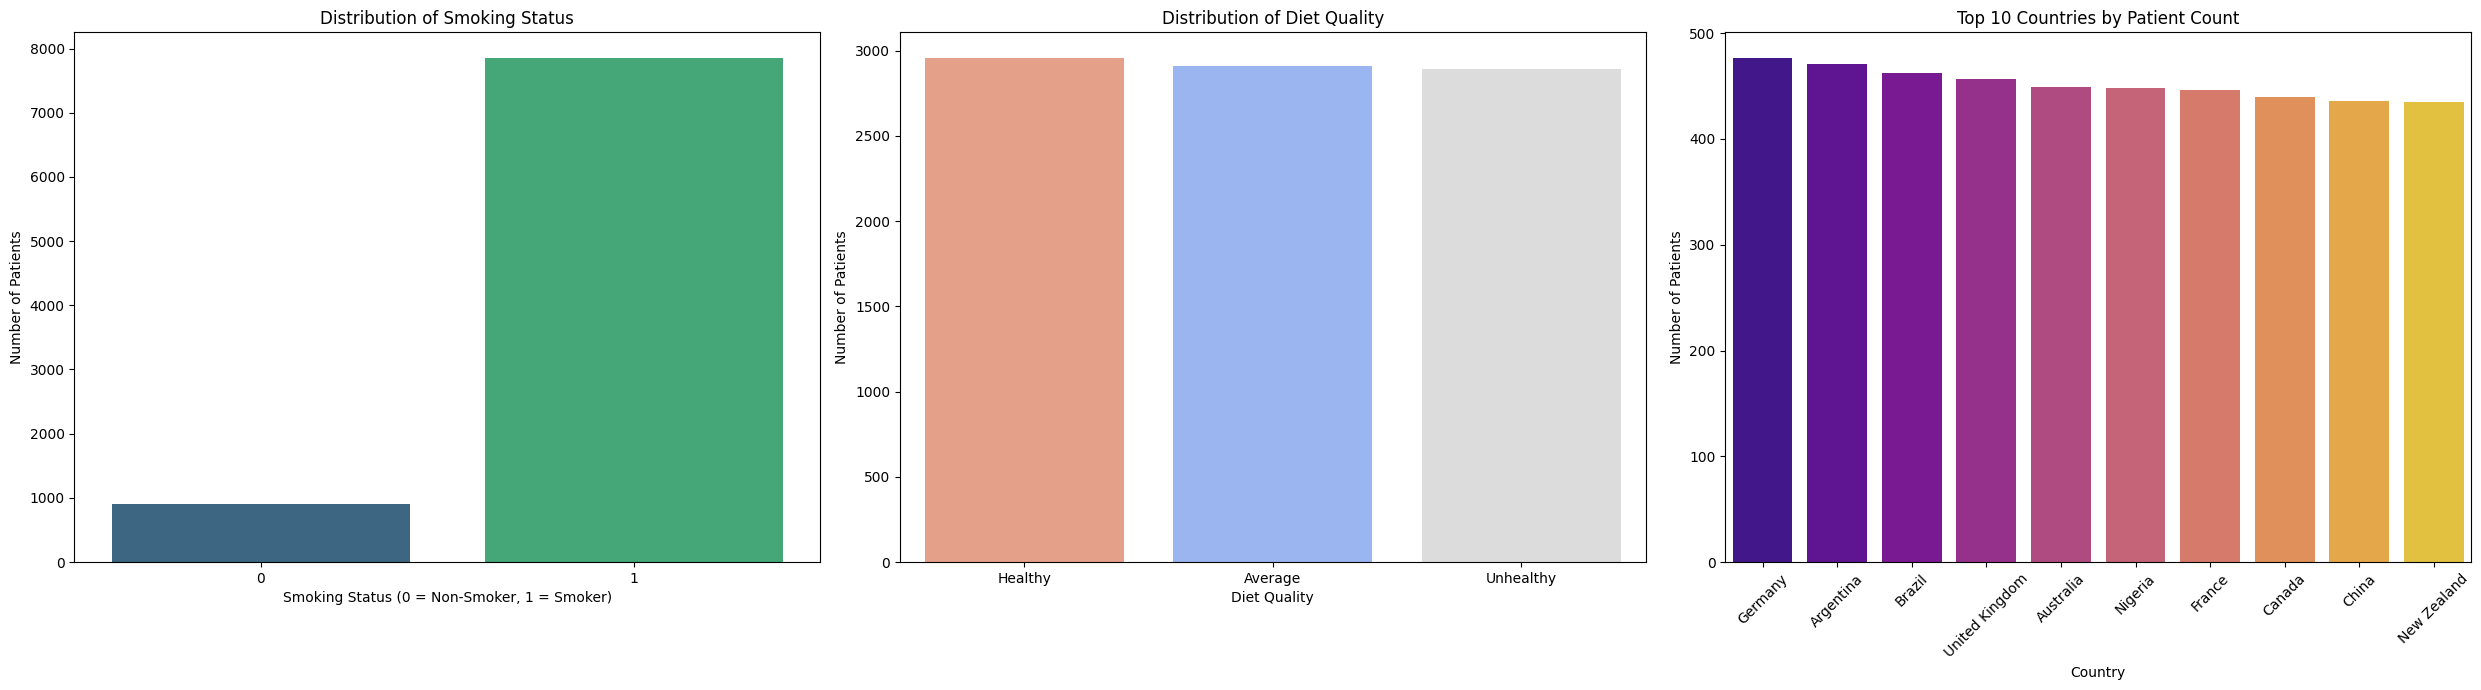

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(25, 7))

# Smoking Status Distribution
sns.countplot(x='Smoking', data=lifestyle, palette='viridis', hue='Smoking', legend=False, ax=axes[0])
axes[0].set_title('Distribution of Smoking Status')
axes[0].set_xlabel('Smoking Status (0 = Non-Smoker, 1 = Smoker)')
axes[0].set_ylabel('Number of Patients')

# Diet Quality Distribution
sns.countplot(x='Diet', data=lifestyle, palette='coolwarm', order=lifestyle['Diet'].value_counts().index, hue='Diet', legend=False, ax=axes[1])
axes[1].set_title('Distribution of Diet Quality')
axes[1].set_xlabel('Diet Quality')
axes[1].set_ylabel('Number of Patients')

# Top 10 Countries Distribution
top_10_countries = demographics['Country'].value_counts().head(10)
sns.barplot(x=top_10_countries.index, y=top_10_countries.values, palette='plasma', hue=top_10_countries.index, legend=False, ax=axes[2])
axes[2].set_title('Top 10 Countries by Patient Count')
axes[2].set_xlabel('Country')
axes[2].set_ylabel('Number of Patients')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

These plots shows the distrubiton on categorical variabls.

Distribution of Smoking Status:
1. There appears to be huge difference (roughtly 80% higher smoker count) in the number of patients where smoker count is around 7800 and non-smoker count is 800
2. Smoker patients likely introduce bias in the analysis.

Distribution of Diet quality:
1. There appears to be roughly equal number of patients on all three categories.

Distrubiton of Top country:
1. Germany leads here which is closly followed by Argentina.
2. There doesnt appears to be the big margin difference on the number of patients in the Top 10 countries.



# Bivariate Analysis : Features vs Target


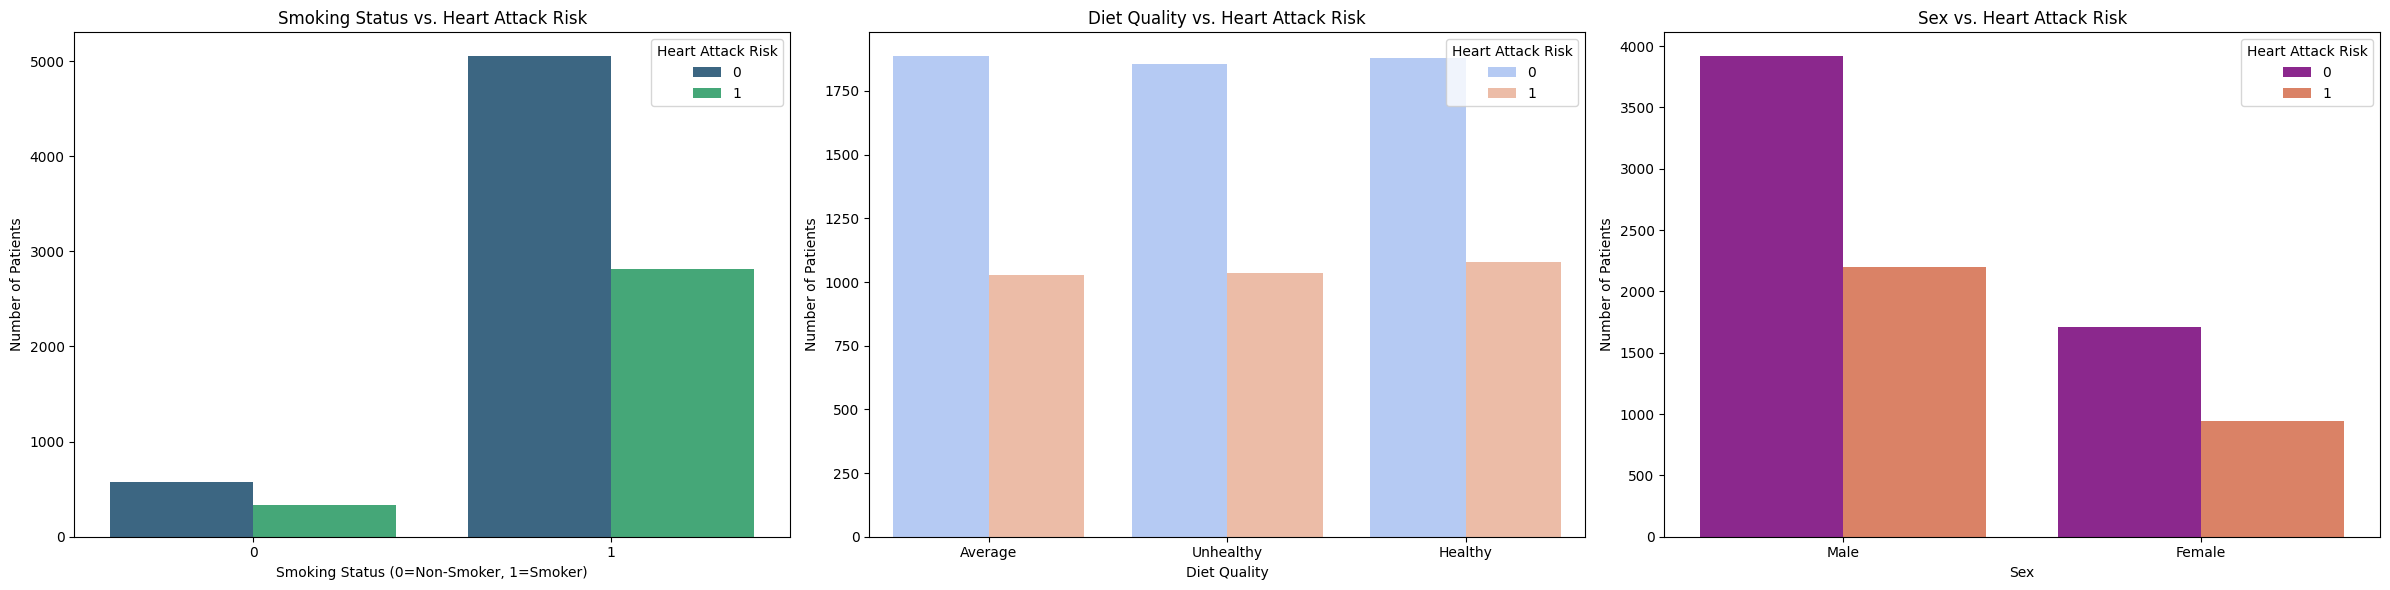

In [ ]:
# Merge demographics and lifestyle dataframes to include 'Sex' and 'Heart Attack Risk'
merged_data = pd.merge(demographics, lifestyle, on='Patient ID', how='inner')

fig, axes = plt.subplots(1, 3, figsize=(24, 6))

# Smoking vs Heart Attack Risk
sns.countplot(x='Smoking', hue='Heart Attack Risk', data=lifestyle, palette='viridis', ax=axes[0])
axes[0].set_title('Smoking Status vs. Heart Attack Risk')
axes[0].set_xlabel('Smoking Status (0=Non-Smoker, 1=Smoker)')
axes[0].set_ylabel('Number of Patients')
axes[0].legend(title='Heart Attack Risk')

# Diet vs Heart Attack Risk
sns.countplot(x='Diet', hue='Heart Attack Risk', data=lifestyle, palette='coolwarm', ax=axes[1])
axes[1].set_title('Diet Quality vs. Heart Attack Risk')
axes[1].set_xlabel('Diet Quality')
axes[1].set_ylabel('Number of Patients')
axes[1].legend(title='Heart Attack Risk')

# Sex vs Heart Attack Risk
sns.countplot(x='Sex', hue='Heart Attack Risk', data=merged_data, palette='plasma', ax=axes[2])
axes[2].set_title('Sex vs. Heart Attack Risk')
axes[2].set_xlabel('Sex')
axes[2].set_ylabel('Number of Patients')
axes[2].legend(title='Heart Attack Risk')

plt.tight_layout()
plt.show()

The Heart attack risk with single category isn't enough to predict the analysis for this dataset. The ratio between different category is roughtly the same (2:1) across all three plots.

vs Smoking status
1. Surprisngly, the smoker patient has low heart-attack risk.

vs Diet quality
1. All three category has the same no risk, this column might just be noise which will not be that useful on the model analysis.

vs Sex
1. This plot shows roughtly the same percentage risk on both the sex.

Analysis (prediction) for heart-attack risk wont be sufficient with one single category. We might have to merge other categories to identify the pattern to see the Heart attack risk.

# Correlation Analysis


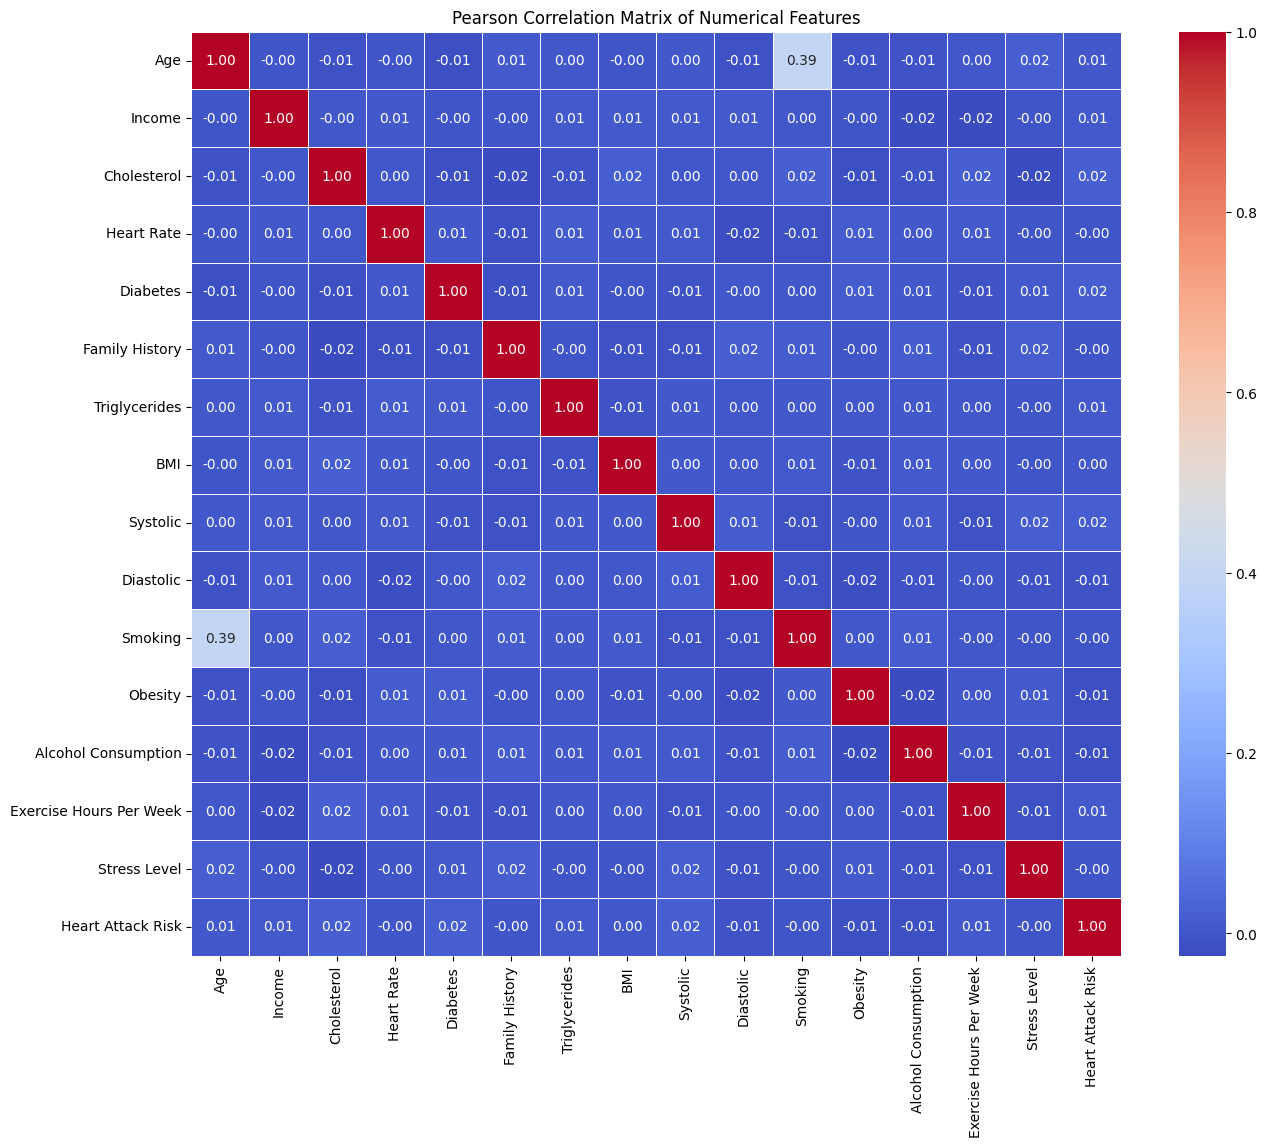

In [ ]:
full_merged_data = pd.merge(demographics, clinical, on='Patient ID', how='outer')
full_merged_data = pd.merge(full_merged_data, lifestyle, on='Patient ID', how='outer')

# Select only numerical columns for correlation analysis
numerical_cols = full_merged_data.select_dtypes(include=np.number).columns
correlation_matrix = full_merged_data[numerical_cols].corr(method='pearson')

plt.figure(figsize=(15, 12))
sns.heatmap(correlation_matrix, annot=True,  cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Pearson Correlation Matrix of Numerical Features')
plt.show()

(Looked with inner and outer join, both illustrated the same data)

- The age and smoking has moderate positive correlation with eachother.
- the heart attack risk has no corelation with any other column.


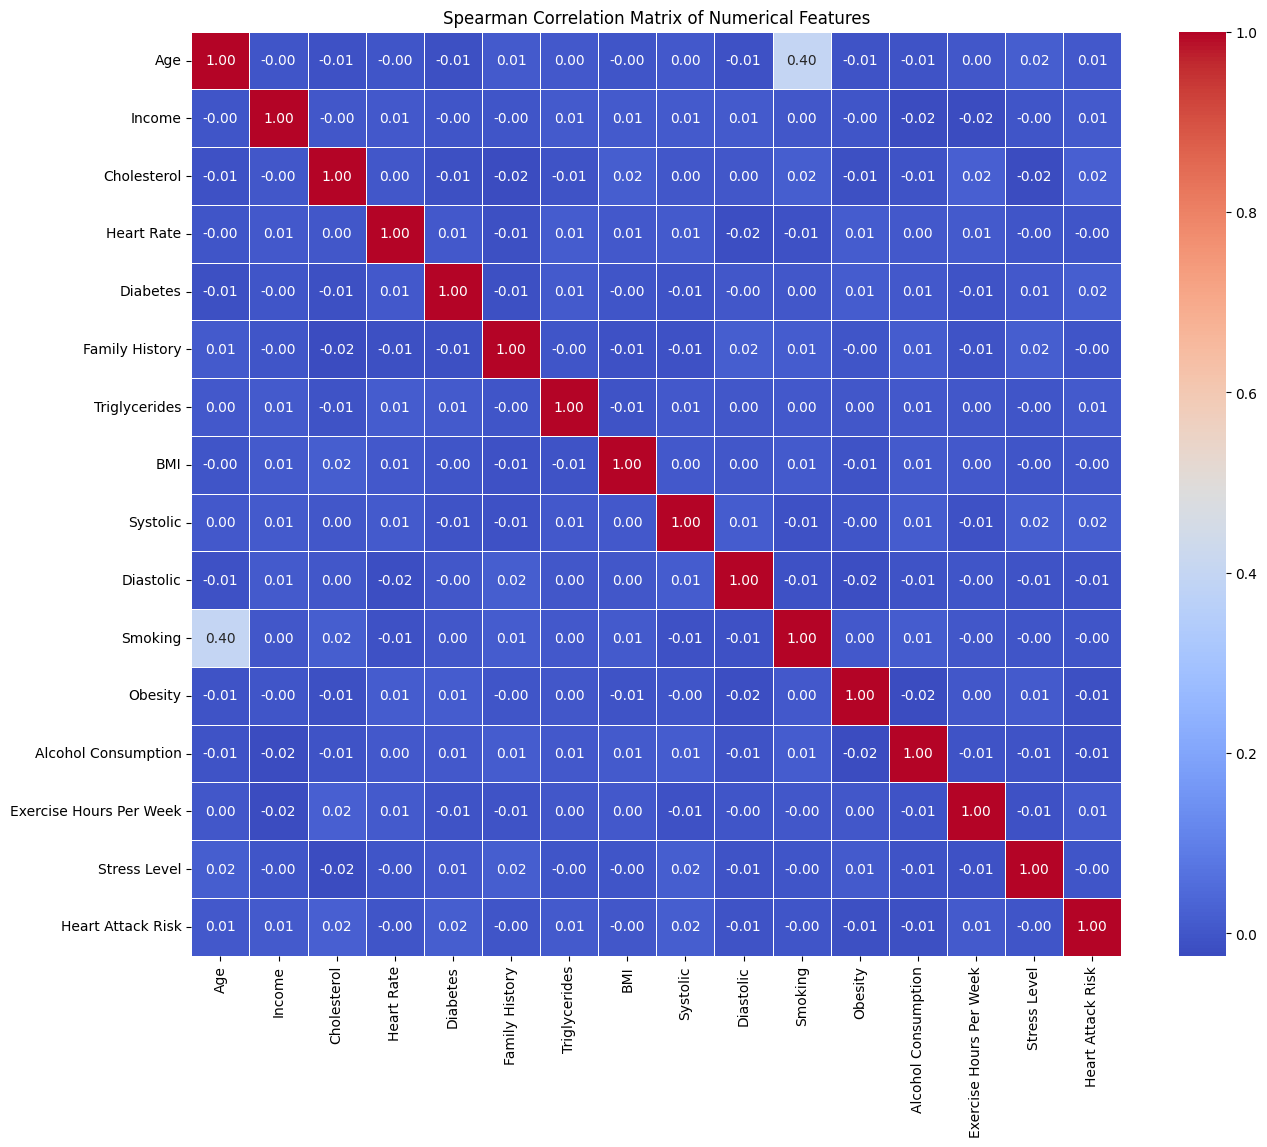

In [ ]:
full_merged_data = pd.merge(demographics, clinical, on='Patient ID', how='outer')
full_merged_data = pd.merge(full_merged_data, lifestyle, on='Patient ID', how='outer')

# Select only numerical columns for correlation analysis
numerical_cols = full_merged_data.select_dtypes(include=np.number).columns
correlation_matrix = full_merged_data[numerical_cols].corr(method='spearman')

plt.figure(figsize=(15, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Spearman Correlation Matrix of Numerical Features')
plt.show()

From the Spearman and Pearson, both are near equivalance. The dataset tends to have no hidden non-linear patterns. The dataset also has no extreme outliers present.

## Target Variable Analysis: Heart Attack Risk

Distribution of Heart Attack Risk:
Heart Attack Risk
0.0    5624
1.0    3139
Name: count, dtype: int64


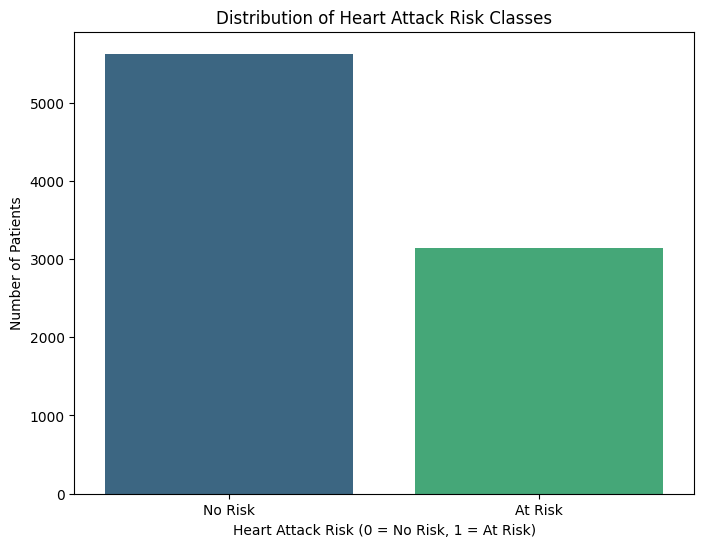

In [ ]:
# Count the number of patients in each class of 'Heart Attack Risk'
risk_counts = full_merged_data['Heart Attack Risk'].value_counts()
print("Distribution of Heart Attack Risk:")
print(risk_counts)

# Visualize the class distribution with a bar chart
plt.figure(figsize=(8, 6))
sns.countplot(x='Heart Attack Risk', data=full_merged_data, palette='viridis', hue='Heart Attack Risk', legend=False)
plt.title('Distribution of Heart Attack Risk Classes')
plt.xlabel('Heart Attack Risk (0 = No Risk, 1 = At Risk)')
plt.ylabel('Number of Patients')
plt.xticks(ticks=[0, 1], labels=['No Risk', 'At Risk'])
plt.show()

The current distribution of Heart attack risk on this dataset leans towards no risk for over 5000 patients. The risk ratio is almost 2:1, no risk to at risk.